# 🛒 E-Commerce Full Data Pipeline
### Data Merging → EDA → Feature Engineering → ML Modeling

**Dataset:** 6 CSV files — orders, order_items, order_item_refunds, products, website_sessions, website_pageviews  
**Target:** Predict whether an order will be refunded (`has_refund`)

---

## 📦 0. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import os

# ── Paths ──────────────────────────────────────────────────────────────────
BASE = "/mnt/user-data/uploads"
OUT  = "/mnt/user-data/outputs"
os.makedirs(OUT, exist_ok=True)

PALETTE = ["#2D6A4F", "#40916C", "#52B788", "#74C69D", "#95D5B2",
           "#B7E4C7", "#D8F3DC", "#F4A261", "#E76F51", "#264653"]
sns.set_theme(style="whitegrid", palette=PALETTE, font_scale=1.05)

print("✅ Imports complete")

✅ Imports complete


## 📂 1. Load & Merge All Data

### Merge Strategy
```
order_items
    └── + order_item_refunds  (left join on order_item_id)
    └── + products             (left join on product_id)
    └── aggregate to order level
orders
    └── + order aggregates     (left join on order_id)
    └── + website_sessions     (left join on website_session_id)
    └── + pageview aggregates  (left join on website_session_id)
```

In [2]:
# ── Load all files ─────────────────────────────────────────────────────────
orders = pd.read_csv(r"C:\Users\Admin\Documents\Rinsha\Data Analysis Project\E commerse\Data\orders.csv",parse_dates=["created_at"])
order_items = pd.read_csv(r"C:\Users\Admin\Documents\Rinsha\Data Analysis Project\E commerse\Data\order_items.csv",parse_dates=["created_at"])
refunds = pd.read_csv(r"C:\Users\Admin\Documents\Rinsha\Data Analysis Project\E commerse\Data\order_item_refunds.csv",parse_dates=["created_at"])
products= pd.read_csv(r"C:\Users\Admin\Documents\Rinsha\Data Analysis Project\E commerse\Data\products.csv",parse_dates=["created_at"])
pageviews= pd.read_csv(r"C:\Users\Admin\Documents\Rinsha\Data Analysis Project\E commerse\Data\website_pageviews.csv",parse_dates=["created_at"])
sessions=pd.read_csv(r"C:\Users\Admin\Documents\Rinsha\Data Analysis Project\E commerse\Data\website_sessions.csv",parse_dates=["created_at"])


print("Raw shapes:")
for name, d in [("orders", orders), ("order_items", order_items), ("refunds", refunds),
                ("products", products), ("sessions", sessions), ("pageviews", pageviews)]:
    print(f"  {name:<20} {d.shape}")

Raw shapes:
  orders               (32313, 8)
  order_items          (40025, 7)
  refunds              (1731, 5)
  products             (4, 3)
  sessions             (472871, 9)
  pageviews            (1188124, 4)


In [3]:
# ── Rename timestamps to avoid collision after merge ──────────────────────
orders.rename(columns={"created_at": "order_created_at"}, inplace=True)
order_items.rename(columns={"created_at": "item_created_at"}, inplace=True)
refunds.rename(columns={"created_at": "refund_created_at"}, inplace=True)
sessions.rename(columns={"created_at": "session_created_at"}, inplace=True)
pageviews.rename(columns={"created_at": "pv_created_at"}, inplace=True)
products.rename(columns={"created_at": "product_launched_at"}, inplace=True)

# ── Refund flag per order_item ─────────────────────────────────────────────
refund_agg = (
    refunds.groupby("order_item_id")
    .agg(refund_amount=("refund_amount_usd", "sum"),
         is_refunded=("order_item_id", "count"))
    .reset_index()
)
refund_agg["is_refunded"] = 1

# ── Pageview aggregates per session ───────────────────────────────────────
pv_agg = (
    pageviews.groupby("website_session_id")
    .agg(
        total_pageviews=("website_pageview_id", "count"),
        unique_pages=("pageview_url", "nunique"),
        visited_cart=("pageview_url", lambda x: int("/cart" in x.values)),
        visited_billing=("pageview_url", lambda x: int("/billing" in x.values)),
        visited_thankyou=("pageview_url", lambda x: int("/thank-you-for-your-order" in x.values)),
        first_page=("pageview_url", "first"),
        last_page=("pageview_url", "last"),
    )
    .reset_index()
)

print("✅ Aggregations built")

✅ Aggregations built


In [19]:
refund_agg

,order_item_id,refund_amount,is_refunded
0,57,49.99,1
1,71,49.99,1
2,74,49.99,1
3,116,49.99,1
4,118,49.99,1
...,...,...,...
1726,39813,49.99,1
1727,39819,45.99,1
1728,39860,49.99,1
1729,39947,45.99,1


In [20]:
pv_agg

,website_session_id,total_pageviews,unique_pages,visited_cart,visited_billing,visited_thankyou,first_page,last_page
0,1,1,1,0,0,0,/home,/home
1,2,1,1,0,0,0,/home,/home
2,3,1,1,0,0,0,/home,/home
3,4,1,1,0,0,0,/home,/home
4,5,1,1,0,0,0,/home,/home
...,...,...,...,...,...,...,...,...
472866,472867,2,2,0,0,0,/home,/products
472867,472868,3,3,0,0,0,/lander-3,/the-original-mr-fuzzy
472868,472869,1,1,0,0,0,/lander-3,/lander-3
472869,472870,3,3,0,0,0,/lander-5,/the-original-mr-fuzzy


In [4]:
# ── Core merge chain ───────────────────────────────────────────────────────
# Step 1: order_items + refunds
oi = order_items.merge(refund_agg[["order_item_id","refund_amount","is_refunded"]],
                       on="order_item_id", how="left")
oi["is_refunded"]   = oi["is_refunded"].fillna(0).astype(int)
oi["refund_amount"] = oi["refund_amount"].fillna(0)

# Step 2: + products
oi = oi.merge(products[["product_id","product_name","product_launched_at"]],
              on="product_id", how="left")

# Step 3: aggregate to order level
order_agg = (
    oi.groupby("order_id")
    .agg(
        total_items=("order_item_id", "count"),
        total_item_revenue=("price_usd", "sum"),
        total_item_cogs=("cogs_usd", "sum"),
        refunded_items=("is_refunded", "sum"),
        total_refund_amount=("refund_amount", "sum"),
        has_refund=("is_refunded", "max"),
    )
    .reset_index()
)

# Step 4: + orders
df = orders.merge(order_agg, on="order_id", how="left")

# Step 5: + sessions
df = df.merge(
    sessions[["website_session_id","session_created_at","user_id",
              "is_repeat_session","utm_source","utm_campaign",
              "utm_content","device_type","http_referer"]],
    on="website_session_id", how="left"
)

# Step 6: + pageviews
df = df.merge(pv_agg, on="website_session_id", how="left")

# Add product name for primary product
prod_map = products.set_index("product_id")["product_name"].to_dict()
df["primary_product_name"] = df["primary_product_id"].map(prod_map)

print(f"✅ Final merged shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")

✅ Final merged shape: (32313, 30)

Columns: ['order_id', 'order_created_at', 'website_session_id', 'user_id_x', 'primary_product_id', 'items_purchased', 'price_usd', 'cogs_usd', 'total_items', 'total_item_revenue', 'total_item_cogs', 'refunded_items', 'total_refund_amount', 'has_refund', 'session_created_at', 'user_id_y', 'is_repeat_session', 'utm_source', 'utm_campaign', 'utm_content', 'device_type', 'http_referer', 'total_pageviews', 'unique_pages', 'visited_cart', 'visited_billing', 'visited_thankyou', 'first_page', 'last_page', 'primary_product_name']


In [21]:
order_agg

,order_id,total_items,total_item_revenue,total_item_cogs,refunded_items,total_refund_amount,has_refund
0,1,1,49.99,19.49,0,0.0,0
1,2,1,49.99,19.49,0,0.0,0
2,3,1,49.99,19.49,0,0.0,0
3,4,1,49.99,19.49,0,0.0,0
4,5,1,49.99,19.49,0,0.0,0
...,...,...,...,...,...,...,...
32308,32309,1,49.99,19.49,0,0.0,0
32309,32310,1,29.99,9.49,0,0.0,0
32310,32311,2,89.98,31.98,0,0.0,0
32311,32312,1,29.99,9.49,0,0.0,0


In [22]:
df

,order_id,order_created_at,website_session_id,user_id_x,primary_product_id,items_purchased,price_usd,cogs_usd,total_items,total_item_revenue,...,unique_pages,visited_cart,visited_billing,visited_thankyou,first_page,last_page,primary_product_name,order_dayofweek,order_hour,gross_margin
0,1,2012-03-19 10:42:46,20,20,1,1,49.99,19.49,1,49.99,...,7,1,1,1,/home,/thank-you-for-your-order,The Original Mr. Fuzzy,0,10,30.5
1,2,2012-03-19 19:27:37,104,104,1,1,49.99,19.49,1,49.99,...,7,1,1,1,/home,/thank-you-for-your-order,The Original Mr. Fuzzy,0,19,30.5
2,3,2012-03-20 06:44:45,147,147,1,1,49.99,19.49,1,49.99,...,7,1,1,1,/home,/thank-you-for-your-order,The Original Mr. Fuzzy,1,6,30.5
3,4,2012-03-20 09:41:45,160,160,1,1,49.99,19.49,1,49.99,...,7,1,1,1,/home,/thank-you-for-your-order,The Original Mr. Fuzzy,1,9,30.5
4,5,2012-03-20 11:28:15,177,177,1,1,49.99,19.49,1,49.99,...,7,1,1,1,/home,/thank-you-for-your-order,The Original Mr. Fuzzy,1,11,30.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32308,32309,2015-03-19 03:58:12,472795,394255,1,1,49.99,19.49,1,49.99,...,7,1,0,1,/lander-5,/thank-you-for-your-order,The Original Mr. Fuzzy,3,3,30.5
32309,32310,2015-03-19 04:10:43,472798,394257,4,1,29.99,9.49,1,29.99,...,7,1,0,1,/lander-5,/thank-you-for-your-order,The Hudson River Mini bear,3,4,20.5
32310,32311,2015-03-19 05:27:28,472809,394268,2,2,89.98,31.98,2,89.98,...,7,1,0,1,/lander-5,/thank-you-for-your-order,The Forever Love Bear,3,5,58.0
32311,32312,2015-03-19 05:35:57,472814,394273,4,1,29.99,9.49,1,29.99,...,7,1,0,1,/lander-5,/thank-you-for-your-order,The Hudson River Mini bear,3,5,20.5


In [5]:
# ── Save merged dataset ────────────────────────────────────────────────────
df.to_csv(f"{OUT}/merged_ecommerce.csv", index=False)
print("✅ merged_ecommerce.csv saved")
df.head()

✅ merged_ecommerce.csv saved


,order_id,order_created_at,website_session_id,user_id_x,primary_product_id,items_purchased,price_usd,cogs_usd,total_items,total_item_revenue,...,device_type,http_referer,total_pageviews,unique_pages,visited_cart,visited_billing,visited_thankyou,first_page,last_page,primary_product_name
0,1,2012-03-19 10:42:46,20,20,1,1,49.99,19.49,1,49.99,...,desktop,https://www.gsearch.com,7,7,1,1,1,/home,/thank-you-for-your-order,The Original Mr. Fuzzy
1,2,2012-03-19 19:27:37,104,104,1,1,49.99,19.49,1,49.99,...,desktop,https://www.gsearch.com,7,7,1,1,1,/home,/thank-you-for-your-order,The Original Mr. Fuzzy
2,3,2012-03-20 06:44:45,147,147,1,1,49.99,19.49,1,49.99,...,desktop,https://www.gsearch.com,7,7,1,1,1,/home,/thank-you-for-your-order,The Original Mr. Fuzzy
3,4,2012-03-20 09:41:45,160,160,1,1,49.99,19.49,1,49.99,...,desktop,https://www.gsearch.com,7,7,1,1,1,/home,/thank-you-for-your-order,The Original Mr. Fuzzy
4,5,2012-03-20 11:28:15,177,177,1,1,49.99,19.49,1,49.99,...,desktop,https://www.gsearch.com,7,7,1,1,1,/home,/thank-you-for-your-order,The Original Mr. Fuzzy


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32313 entries, 0 to 32312
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   order_id              32313 non-null  int64         
 1   order_created_at      32313 non-null  datetime64[ns]
 2   website_session_id    32313 non-null  int64         
 3   user_id_x             32313 non-null  int64         
 4   primary_product_id    32313 non-null  int64         
 5   items_purchased       32313 non-null  int64         
 6   price_usd             32313 non-null  float64       
 7   cogs_usd              32313 non-null  float64       
 8   total_items           32313 non-null  int64         
 9   total_item_revenue    32313 non-null  float64       
 10  total_item_cogs       32313 non-null  float64       
 11  refunded_items        32313 non-null  int64         
 12  total_refund_amount   32313 non-null  float64       
 13  has_refund      

## 🔍 2. Exploratory Data Analysis (EDA)

In [6]:
# ── Null & dtype overview ──────────────────────────────────────────────────
info = pd.DataFrame({
    "dtype": df.dtypes,
    "null_count": df.isnull().sum(),
    "null_pct": (df.isnull().sum() / len(df) * 100).round(2)
})
print("Columns with nulls:")
display(info[info.null_count > 0])

Columns with nulls:


,dtype,null_count,null_pct
utm_source,object,6118,18.93
utm_campaign,object,6118,18.93
utm_content,object,6118,18.93
http_referer,object,2856,8.84


In [7]:
# ── Numeric summary ────────────────────────────────────────────────────────
df.describe().T

,count,mean,min,25%,50%,75%,max,std
order_id,32313.0,16157.0,1.0,8079.0,16157.0,24235.0,32313.0,9328.103961
order_created_at,32313,2014-04-14 03:01:01.276823552,2012-03-19 10:42:46,2013-10-30 14:30:35,2014-06-11 14:27:02,2014-11-28 10:53:48,2015-03-19 05:38:31,NaN
website_session_id,32313.0,258292.288707,20.0,144828.0,263554.0,374799.0,472818.0,132427.649842
user_id_x,32313.0,215691.622629,13.0,124135.0,221461.0,310542.0,394273.0,108402.203189
primary_product_id,32313.0,1.392474,1.0,1.0,1.0,2.0,4.0,0.732277
items_purchased,32313.0,1.238666,1.0,1.0,1.0,1.0,2.0,0.426274
price_usd,32313.0,59.991636,29.99,49.99,49.99,59.99,109.98,17.808771
cogs_usd,32313.0,22.355406,9.49,19.49,19.49,22.49,41.98,6.238621
total_items,32313.0,1.238666,1.0,1.0,1.0,1.0,2.0,0.426274
total_item_revenue,32313.0,59.991636,29.99,49.99,49.99,59.99,109.98,17.808771


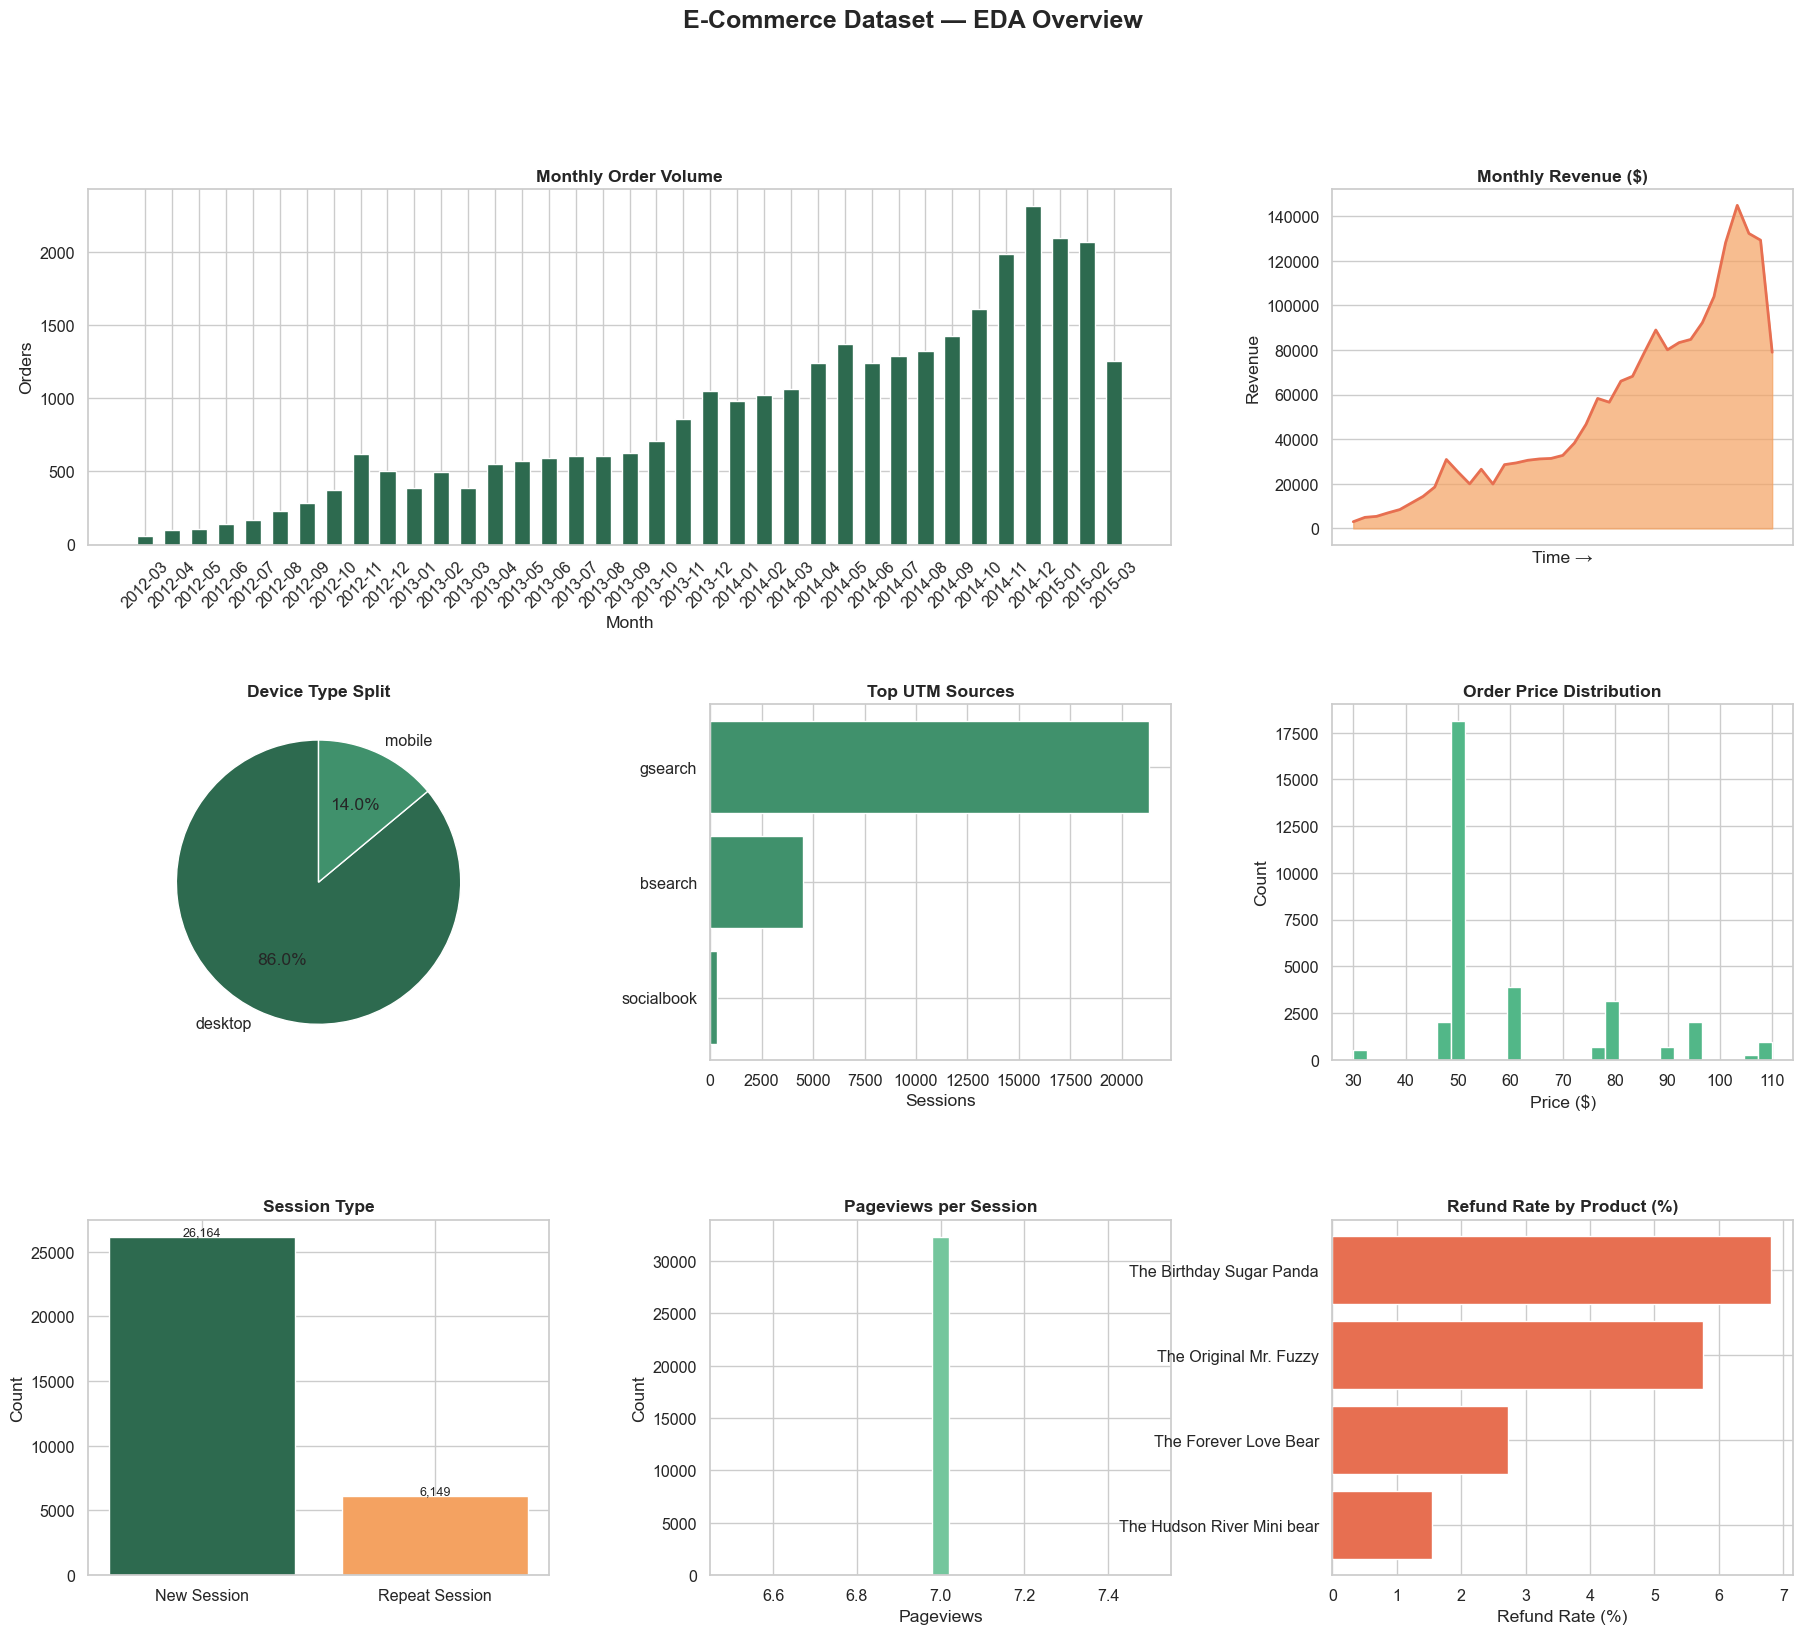

In [8]:
# ── Figure 1: EDA Overview Dashboard ──────────────────────────────────────
fig = plt.figure(figsize=(22, 18))
fig.suptitle("E-Commerce Dataset — EDA Overview", fontsize=18, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

df["order_dayofweek"] = df["order_created_at"].dt.dayofweek
df["order_hour"] = df["order_created_at"].dt.hour

# Monthly orders
ax1 = fig.add_subplot(gs[0, :2])
monthly = df.groupby(df["order_created_at"].dt.to_period("M")).size()
monthly.index = monthly.index.astype(str)
ax1.bar(monthly.index, monthly.values, color=PALETTE[0], edgecolor="white", width=0.6)
ax1.set_title("Monthly Order Volume", fontweight="bold")
ax1.set_xlabel("Month"); ax1.set_ylabel("Orders")
ax1.tick_params(axis="x", rotation=45)

# Monthly revenue
ax2 = fig.add_subplot(gs[0, 2])
rev_monthly = df.groupby(df["order_created_at"].dt.to_period("M"))["price_usd"].sum()
rev_monthly.index = rev_monthly.index.astype(str)
ax2.fill_between(range(len(rev_monthly)), rev_monthly.values, alpha=0.7, color=PALETTE[7])
ax2.plot(range(len(rev_monthly)), rev_monthly.values, color=PALETTE[8], lw=2)
ax2.set_title("Monthly Revenue ($)", fontweight="bold")
ax2.set_ylabel("Revenue"); ax2.set_xticks([]); ax2.set_xlabel("Time →")

# Device split
ax3 = fig.add_subplot(gs[1, 0])
device_counts = df["device_type"].value_counts()
ax3.pie(device_counts.values, labels=device_counts.index, autopct="%1.1f%%",
        colors=PALETTE[:2], startangle=90)
ax3.set_title("Device Type Split", fontweight="bold")

# UTM source
ax4 = fig.add_subplot(gs[1, 1])
utm = df["utm_source"].value_counts().head(8)
ax4.barh(utm.index[::-1], utm.values[::-1], color=PALETTE[1])
ax4.set_title("Top UTM Sources", fontweight="bold"); ax4.set_xlabel("Sessions")

# Price distribution
ax5 = fig.add_subplot(gs[1, 2])
ax5.hist(df["price_usd"].dropna(), bins=30, color=PALETTE[2], edgecolor="white")
ax5.set_title("Order Price Distribution", fontweight="bold")
ax5.set_xlabel("Price ($)"); ax5.set_ylabel("Count")

# Repeat vs new
ax6 = fig.add_subplot(gs[2, 0])
repeat_counts = df["is_repeat_session"].value_counts()
bars = ax6.bar(["New Session", "Repeat Session"], repeat_counts.values, color=[PALETTE[0], PALETTE[7]])
for bar in bars:
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f"{bar.get_height():,}", ha="center", fontsize=9)
ax6.set_title("Session Type", fontweight="bold"); ax6.set_ylabel("Count")

# Pageviews
ax7 = fig.add_subplot(gs[2, 1])
ax7.hist(df["total_pageviews"].dropna().clip(upper=30), bins=25, color=PALETTE[3], edgecolor="white")
ax7.set_title("Pageviews per Session", fontweight="bold")
ax7.set_xlabel("Pageviews"); ax7.set_ylabel("Count")

# Refund rate by product
ax8 = fig.add_subplot(gs[2, 2])
refund_by_prod = df.groupby("primary_product_name")["has_refund"].mean().sort_values()
ax8.barh(refund_by_prod.index, refund_by_prod.values * 100, color=PALETTE[8])
ax8.set_title("Refund Rate by Product (%)", fontweight="bold"); ax8.set_xlabel("Refund Rate (%)")

plt.savefig(f"{OUT}/eda_overview.png", dpi=140, bbox_inches="tight")
plt.show()

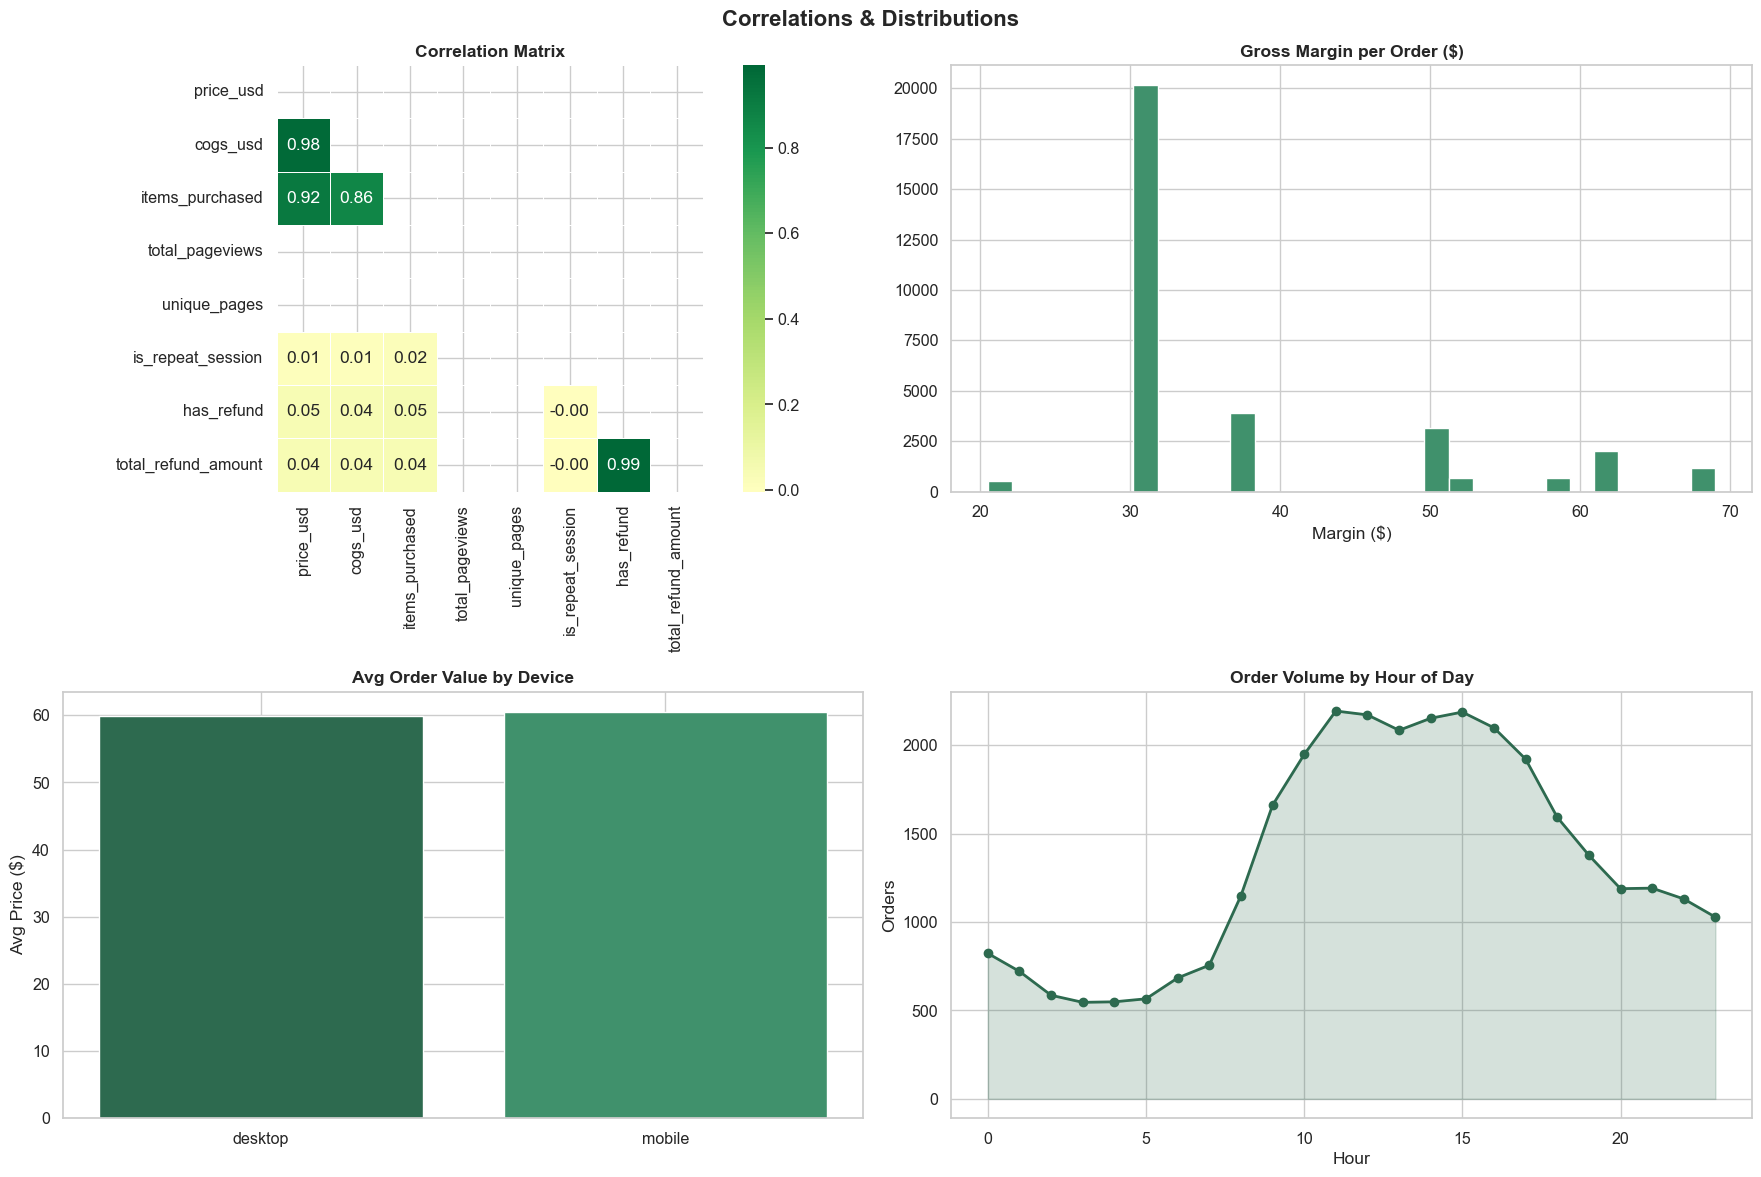

In [9]:
# ── Figure 2: Correlations & Distributions ────────────────────────────────
num_cols = ["price_usd","cogs_usd","items_purchased","total_pageviews",
            "unique_pages","is_repeat_session","has_refund","total_refund_amount"]
num_df = df[num_cols].dropna()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Correlations & Distributions", fontsize=16, fontweight="bold")

# Correlation heatmap
corr = num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=axes[0,0], mask=mask, annot=True, fmt=".2f",
            cmap="RdYlGn", center=0, linewidths=0.5, square=True)
axes[0,0].set_title("Correlation Matrix", fontweight="bold")

# Gross margin
df["gross_margin"] = df["price_usd"] - df["cogs_usd"]
axes[0,1].hist(df["gross_margin"].dropna(), bins=30, color=PALETTE[1], edgecolor="white")
axes[0,1].set_title("Gross Margin per Order ($)", fontweight="bold")
axes[0,1].set_xlabel("Margin ($)")

# Revenue by device
device_rev = df.groupby("device_type")["price_usd"].mean()
axes[1,0].bar(device_rev.index, device_rev.values, color=PALETTE[:2])
axes[1,0].set_title("Avg Order Value by Device", fontweight="bold")
axes[1,0].set_ylabel("Avg Price ($)")

# Hourly pattern
hourly = df.groupby("order_hour").size()
axes[1,1].plot(hourly.index, hourly.values, marker="o", color=PALETTE[0], lw=2)
axes[1,1].fill_between(hourly.index, hourly.values, alpha=0.2, color=PALETTE[0])
axes[1,1].set_title("Order Volume by Hour of Day", fontweight="bold")
axes[1,1].set_xlabel("Hour"); axes[1,1].set_ylabel("Orders")

plt.tight_layout()
plt.savefig(f"{OUT}/eda_correlations.png", dpi=140, bbox_inches="tight")
plt.show()

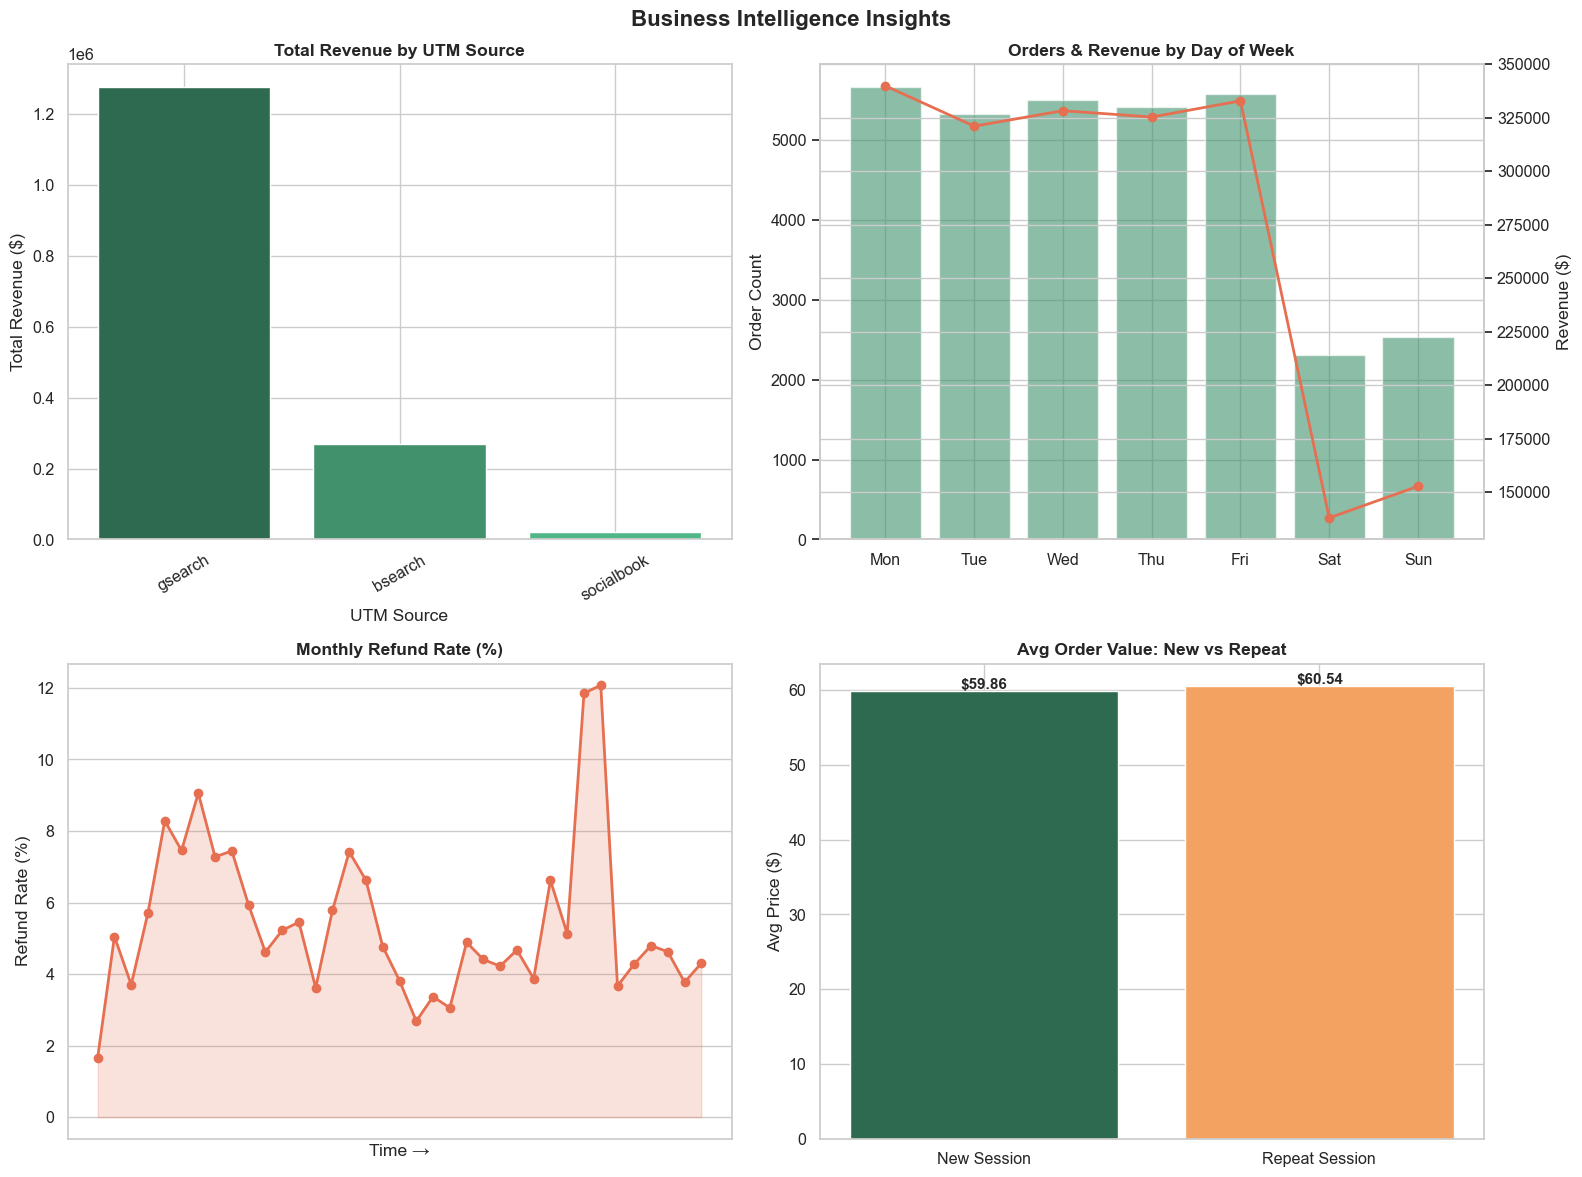

In [10]:
# ── Business Insights ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Business Intelligence Insights", fontsize=16, fontweight="bold")

# Revenue by UTM source
rev_by_src = df.groupby("utm_source")["price_usd"].agg(["sum","count"]).sort_values("sum", ascending=False).head(8)
axes[0,0].bar(rev_by_src.index, rev_by_src["sum"], color=PALETTE[:len(rev_by_src)])
axes[0,0].set_title("Total Revenue by UTM Source", fontweight="bold")
axes[0,0].set_xlabel("UTM Source"); axes[0,0].set_ylabel("Total Revenue ($)")
axes[0,0].tick_params(axis="x", rotation=30)

# Day of week
dow_map = {0:"Mon",1:"Tue",2:"Wed",3:"Thu",4:"Fri",5:"Sat",6:"Sun"}
dow_sales = df.groupby("order_dayofweek")["price_usd"].agg(["sum","count"])
dow_sales.index = [dow_map[i] for i in dow_sales.index]
ax2t = axes[0,1].twinx()
axes[0,1].bar(dow_sales.index, dow_sales["count"], color=PALETTE[1], alpha=0.6)
ax2t.plot(dow_sales.index, dow_sales["sum"], "o-", color=PALETTE[8], lw=2)
axes[0,1].set_title("Orders & Revenue by Day of Week", fontweight="bold")
axes[0,1].set_ylabel("Order Count"); ax2t.set_ylabel("Revenue ($)")

# Monthly refund rate
monthly_refund = df.groupby(df["order_created_at"].dt.to_period("M"))["has_refund"].mean() * 100
monthly_refund.index = monthly_refund.index.astype(str)
axes[1,0].plot(range(len(monthly_refund)), monthly_refund.values, marker="o", color=PALETTE[8], lw=2)
axes[1,0].fill_between(range(len(monthly_refund)), monthly_refund.values, alpha=0.2, color=PALETTE[8])
axes[1,0].set_title("Monthly Refund Rate (%)", fontweight="bold")
axes[1,0].set_ylabel("Refund Rate (%)"); axes[1,0].set_xticks([]); axes[1,0].set_xlabel("Time →")

# AOV: repeat vs new
aov = df.groupby("is_repeat_session")["price_usd"].agg(["mean","count"])
aov.index = ["New Session", "Repeat Session"]
bars2 = axes[1,1].bar(aov.index, aov["mean"], color=[PALETTE[0], PALETTE[7]])
for bar, v in zip(bars2, aov["mean"]):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                   f"${v:.2f}", ha="center", fontsize=11, fontweight="bold")
axes[1,1].set_title("Avg Order Value: New vs Repeat", fontweight="bold")
axes[1,1].set_ylabel("Avg Price ($)")

plt.tight_layout()
plt.savefig(f"{OUT}/business_insights.png", dpi=140, bbox_inches="tight")
plt.show()

## ⚙️ 3. Feature Engineering

We create 27 features grouped into 5 categories:

| Category | Features |
|---|---|
| **Time** | year, month, dayofweek, hour, is_weekend, quarter |
| **Revenue/Margin** | gross_margin, margin_pct, cogs_ratio, revenue_per_item |
| **Engagement** | pages_per_visit, funnel_depth, reached_cart/billing |
| **Refund** | refund_rate, refund_intensity *(excluded from ML to avoid leakage)* |
| **Marketing** | utm_source_enc, utm_campaign_enc, device_type_enc |

In [11]:
fe = df.copy()

# ── Time features ───────────────────────────────────────────────────────────
fe["order_year"]      = fe["order_created_at"].dt.year
fe["order_month"]     = fe["order_created_at"].dt.month
fe["order_dayofweek"] = fe["order_created_at"].dt.dayofweek
fe["order_hour"]      = fe["order_created_at"].dt.hour
fe["is_weekend"]      = (fe["order_dayofweek"] >= 5).astype(int)
fe["order_quarter"]   = fe["order_created_at"].dt.quarter

# ── Revenue & margin features ───────────────────────────────────────────────
fe["gross_margin"]     = fe["price_usd"] - fe["cogs_usd"]
fe["margin_pct"]       = (fe["gross_margin"] / fe["price_usd"]).round(4)
fe["revenue_per_item"] = (fe["price_usd"] / fe["items_purchased"].replace(0, np.nan)).round(2)
fe["cogs_ratio"]       = (fe["cogs_usd"] / fe["price_usd"]).round(4)

# ── Engagement / funnel features ────────────────────────────────────────────
fe["pages_per_visit"] = fe["total_pageviews"] / fe["unique_pages"].replace(0, 1)
fe["reached_cart"]    = fe["visited_cart"].fillna(0).astype(int)
fe["reached_billing"] = fe["visited_billing"].fillna(0).astype(int)
fe["reached_thankyou"]= fe["visited_thankyou"].fillna(0).astype(int)
fe["funnel_depth"]    = fe[["reached_cart","reached_billing","reached_thankyou"]].sum(axis=1)

# ── Refund features (for analysis only, NOT fed into ML) ────────────────────
fe["refund_rate"]      = fe["refunded_items"] / fe["total_items"].replace(0, np.nan)
fe["refund_intensity"] = fe["total_refund_amount"] / fe["price_usd"].replace(0, np.nan)

# ── Marketing channel encoding ──────────────────────────────────────────────
cat_cols = ["utm_source","utm_campaign","utm_content","device_type","http_referer","primary_product_name"]
le = LabelEncoder()
for col in cat_cols:
    fe[col] = fe[col].fillna("unknown")
    fe[col + "_enc"] = le.fit_transform(fe[col].astype(str))

print(f"✅ Feature engineering complete — {fe.shape[1]} total columns")
fe.head()

✅ Feature engineering complete — 53 total columns


,order_id,order_created_at,website_session_id,user_id_x,primary_product_id,items_purchased,price_usd,cogs_usd,total_items,total_item_revenue,...,reached_thankyou,funnel_depth,refund_rate,refund_intensity,utm_source_enc,utm_campaign_enc,utm_content_enc,device_type_enc,http_referer_enc,primary_product_name_enc
0,1,2012-03-19 10:42:46,20,20,1,1,49.99,19.49,1,49.99,...,1,3,0.0,0.0,1,2,2,0,1,3
1,2,2012-03-19 19:27:37,104,104,1,1,49.99,19.49,1,49.99,...,1,3,0.0,0.0,1,2,2,0,1,3
2,3,2012-03-20 06:44:45,147,147,1,1,49.99,19.49,1,49.99,...,1,3,0.0,0.0,1,2,2,0,1,3
3,4,2012-03-20 09:41:45,160,160,1,1,49.99,19.49,1,49.99,...,1,3,0.0,0.0,1,2,2,0,1,3
4,5,2012-03-20 11:28:15,177,177,1,1,49.99,19.49,1,49.99,...,1,3,0.0,0.0,1,2,2,0,1,3


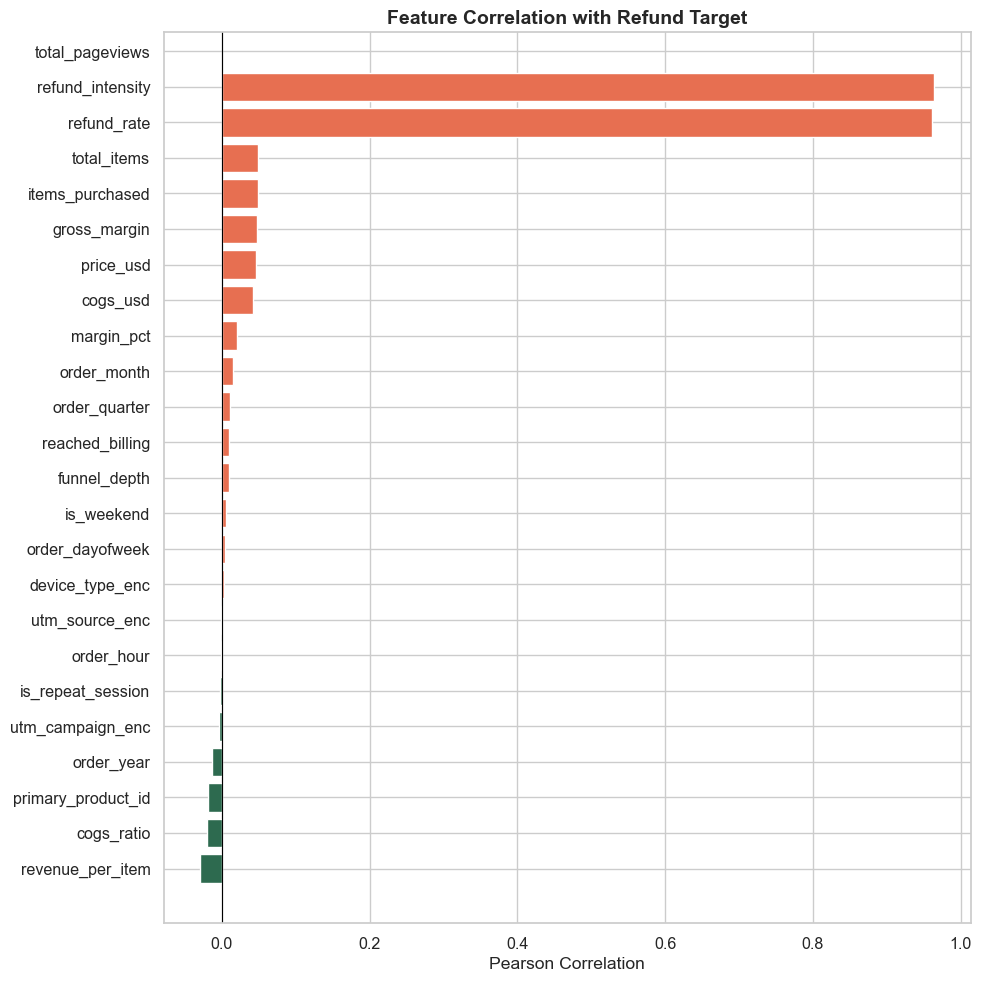

In [12]:
# ── Feature correlation with refund target ─────────────────────────────────
feat_cols_all = [
    "order_year","order_month","order_dayofweek","order_hour","is_weekend","order_quarter",
    "gross_margin","margin_pct","revenue_per_item","cogs_ratio",
    "total_pageviews","unique_pages","pages_per_visit",
    "reached_cart","reached_billing","funnel_depth",
    "refund_rate","refund_intensity","total_items","items_purchased",
    "is_repeat_session","price_usd","cogs_usd",
    "utm_source_enc","utm_campaign_enc","device_type_enc","primary_product_id",
]

target_corr = fe[feat_cols_all + ["has_refund"]].corr()["has_refund"].drop("has_refund").sort_values()
fig, ax = plt.subplots(figsize=(10, 10))
colors = [PALETTE[8] if v > 0 else PALETTE[0] for v in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Feature Correlation with Refund Target", fontsize=14, fontweight="bold")
ax.set_xlabel("Pearson Correlation")
plt.tight_layout()
plt.savefig(f"{OUT}/feature_correlations.png", dpi=140, bbox_inches="tight")
plt.show()

## 🤖 4. Machine Learning — Refund Prediction

**Task:** Binary classification — will this order be refunded?  
**Note:** `refund_rate` and `refund_intensity` are **excluded** to avoid data leakage (they're derived from the target variable).

**Models trained:**
- Logistic Regression (baseline)
- Random Forest
- Gradient Boosting

In [13]:
# ── ML feature set (no leakage) ───────────────────────────────────────────
feat_cols = [
    "order_year","order_month","order_dayofweek","order_hour","is_weekend","order_quarter",
    "gross_margin","margin_pct","cogs_ratio","price_usd","cogs_usd","items_purchased",
    "is_repeat_session","primary_product_id",
    "utm_source_enc","utm_campaign_enc","device_type_enc",
]

ml = fe[feat_cols + ["has_refund"]].dropna(subset=feat_cols)
X = ml[feat_cols]
y = ml["has_refund"].astype(int)

print(f"Dataset : {X.shape[0]:,} rows × {X.shape[1]} features")
print(f"No Refund: {(y==0).sum():,} | Refunded: {(y==1).sum():,}")
print(f"Refund rate: {y.mean():.2%}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {len(X_train):,} | Test: {len(X_test):,}")

Dataset : 32,313 rows × 17 features
No Refund: 30,590 | Refunded: 1,723
Refund rate: 5.33%

Train: 25,850 | Test: 6,463


In [14]:
# ── Define models ──────────────────────────────────────────────────────────
models = {
    "Logistic Regression": Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("scl", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
    ]),
    "Random Forest": Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("clf", RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                        max_depth=8, random_state=42, n_jobs=-1)),
    ]),
    "Gradient Boosting": Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("clf", GradientBoostingClassifier(n_estimators=150, max_depth=5,
                                            learning_rate=0.08, random_state=42)),
    ]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, pipe in models.items():
    print(f"\nTraining {name}...")
    cv_auc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc")
    pipe.fit(X_train, y_train)
    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    auc     = roc_auc_score(y_test, y_proba)
    ap      = average_precision_score(y_test, y_proba)
    results[name] = {
        "pipe": pipe, "y_pred": y_pred, "y_proba": y_proba,
        "auc": auc, "ap": ap,
        "cv_auc_mean": cv_auc.mean(), "cv_auc_std": cv_auc.std(),
        "report": classification_report(y_test, y_pred, output_dict=True),
    }
    print(f"  AUC={auc:.4f} | AP={ap:.4f} | CV-AUC={cv_auc.mean():.4f} ± {cv_auc.std():.4f}")
    print(classification_report(y_test, y_pred))


Training Logistic Regression...
  AUC=0.5856 | AP=0.0784 | CV-AUC=0.5792 ± 0.0118
              precision    recall  f1-score   support

           0       0.96      0.60      0.74      6118
           1       0.07      0.51      0.12       345

    accuracy                           0.60      6463
   macro avg       0.51      0.56      0.43      6463
weighted avg       0.91      0.60      0.71      6463


Training Random Forest...
  AUC=0.6492 | AP=0.0854 | CV-AUC=0.6099 ± 0.0084
              precision    recall  f1-score   support

           0       0.96      0.72      0.83      6118
           1       0.09      0.47      0.15       345

    accuracy                           0.71      6463
   macro avg       0.52      0.60      0.49      6463
weighted avg       0.91      0.71      0.79      6463


Training Gradient Boosting...
  AUC=0.6477 | AP=0.0873 | CV-AUC=0.5986 ± 0.0108
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      6

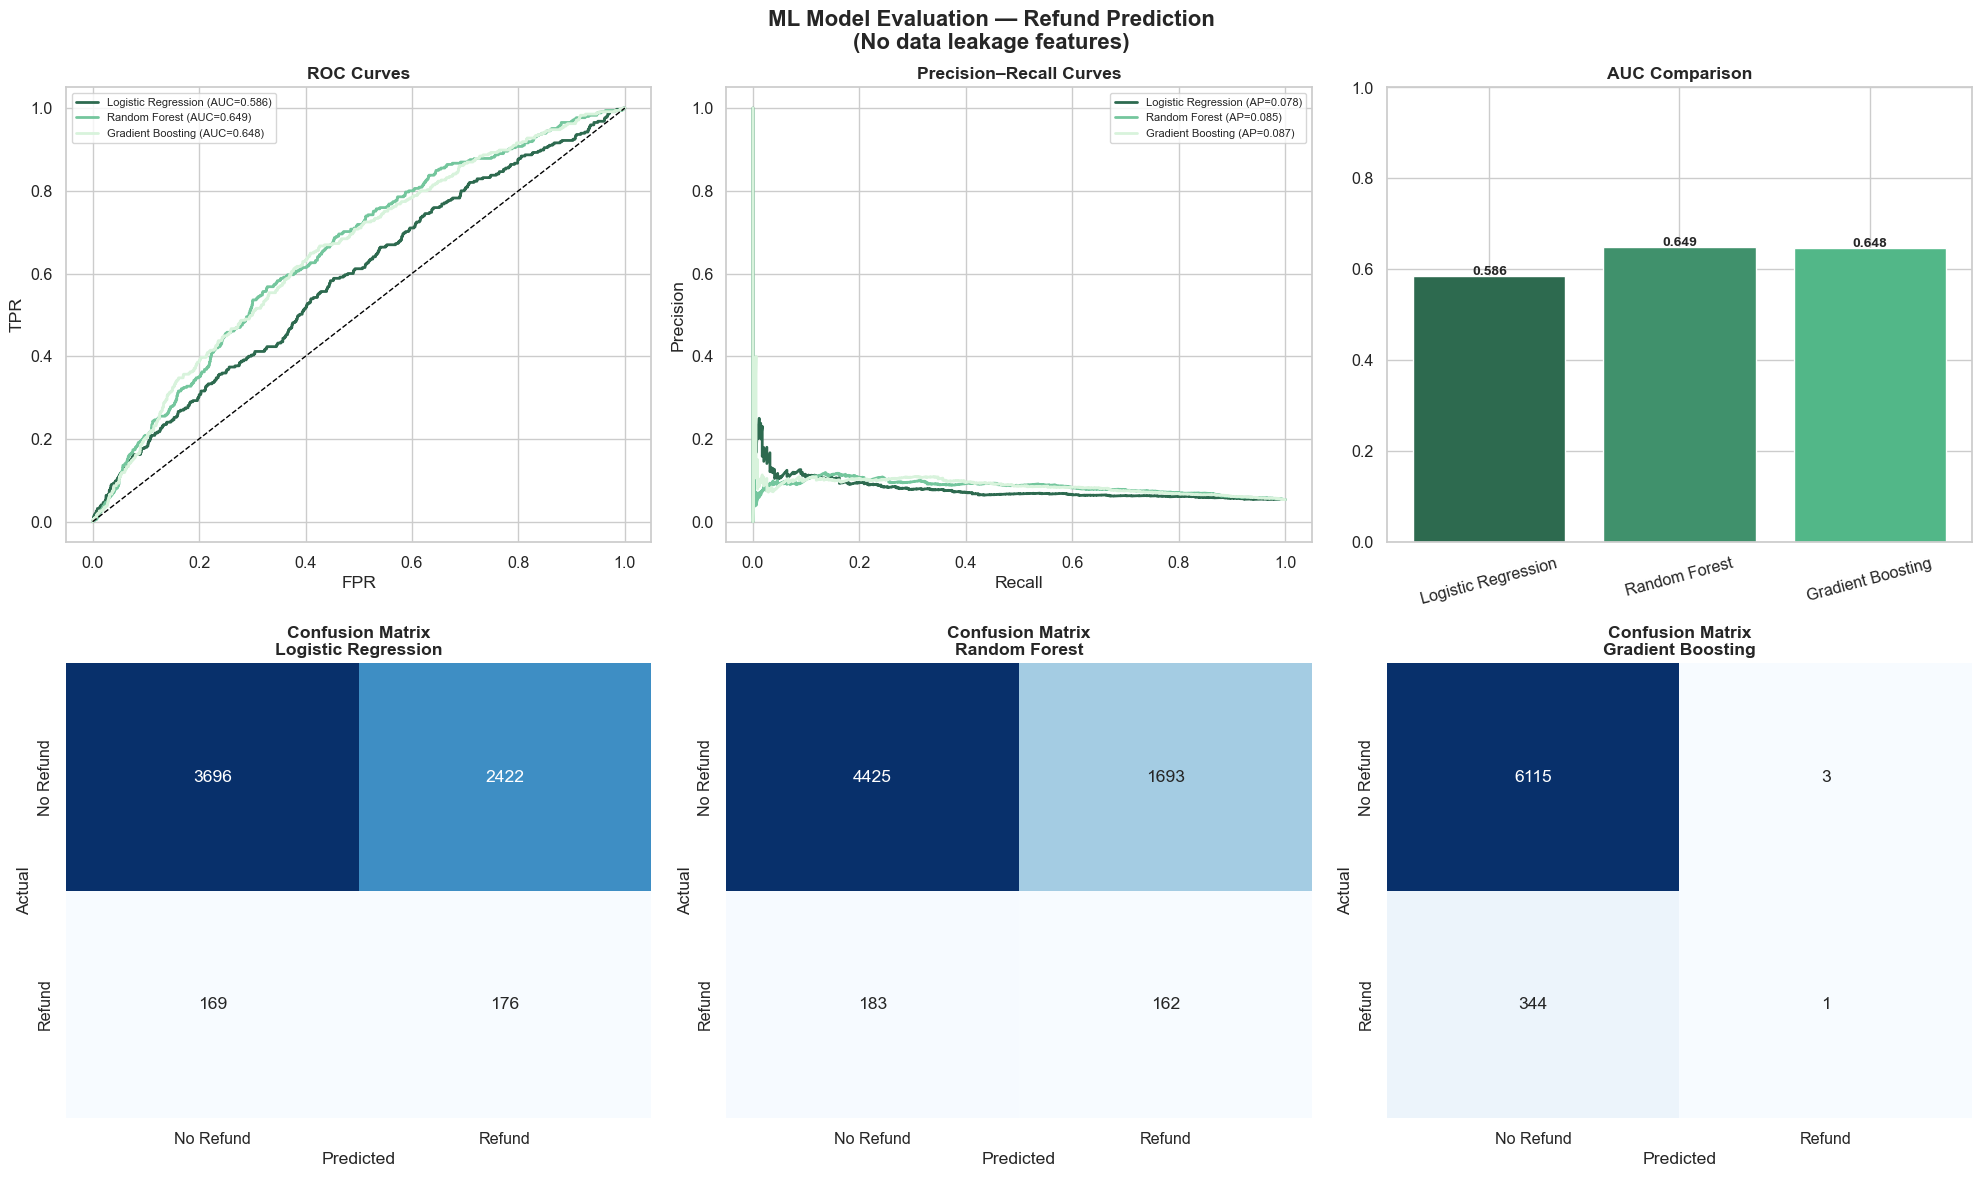

In [15]:
# ── Figure: ROC, PR curves, AUC bar, Confusion matrices ───────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle("ML Model Evaluation — Refund Prediction\n(No data leakage features)", fontsize=16, fontweight="bold")

# ROC
ax = axes[0, 0]
for i, (name, res) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    ax.plot(fpr, tpr, lw=2, color=PALETTE[i*3], label=f"{name} (AUC={res['auc']:.3f})")
ax.plot([0,1],[0,1],"k--", lw=1)
ax.set_title("ROC Curves", fontweight="bold"); ax.set_xlabel("FPR"); ax.set_ylabel("TPR"); ax.legend(fontsize=8)

# Precision-Recall
ax = axes[0, 1]
for i, (name, res) in enumerate(results.items()):
    prec, rec, _ = precision_recall_curve(y_test, res["y_proba"])
    ax.plot(rec, prec, lw=2, color=PALETTE[i*3], label=f"{name} (AP={res['ap']:.3f})")
ax.set_title("Precision–Recall Curves", fontweight="bold"); ax.set_xlabel("Recall"); ax.set_ylabel("Precision"); ax.legend(fontsize=8)

# AUC bar
ax = axes[0, 2]
auc_vals = [res["auc"] for res in results.values()]
bars = ax.bar(list(results.keys()), auc_vals, color=PALETTE[:3])
for bar, v in zip(bars, auc_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{v:.3f}", ha="center", fontsize=10, fontweight="bold")
ax.set_ylim(0, 1); ax.set_title("AUC Comparison", fontweight="bold"); ax.tick_params(axis="x", rotation=15)

# Confusion matrices
for j, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", ax=axes[1, j], cmap="Blues", cbar=False,
                xticklabels=["No Refund","Refund"], yticklabels=["No Refund","Refund"])
    axes[1, j].set_title(f"Confusion Matrix\n{name}", fontweight="bold")
    axes[1, j].set_ylabel("Actual"); axes[1, j].set_xlabel("Predicted")

plt.tight_layout()
plt.savefig(f"{OUT}/ml_evaluation.png", dpi=140, bbox_inches="tight")
plt.show()

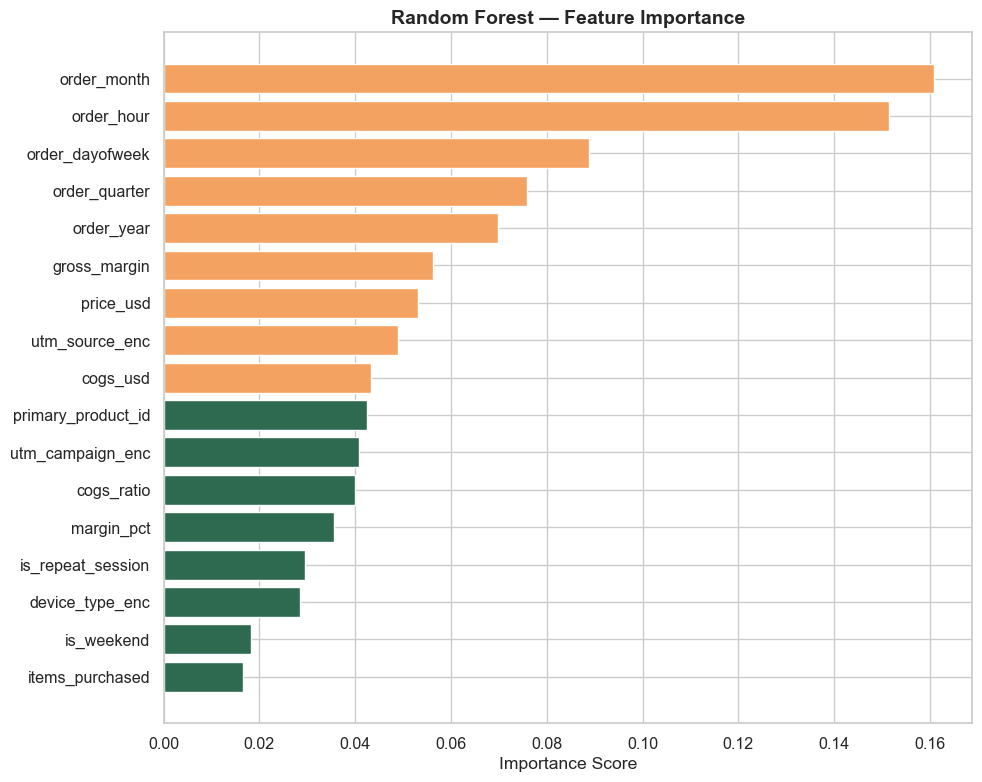

In [16]:
# ── Feature Importance — Random Forest ────────────────────────────────────
rf_clf  = results["Random Forest"]["pipe"].named_steps["clf"]
feat_imp = pd.Series(rf_clf.feature_importances_, index=feat_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors_imp = [PALETTE[0] if v < feat_imp.median() else PALETTE[7] for v in feat_imp.values]
ax.barh(feat_imp.index, feat_imp.values, color=colors_imp)
ax.set_title("Random Forest — Feature Importance", fontsize=14, fontweight="bold")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.savefig(f"{OUT}/feature_importance.png", dpi=140, bbox_inches="tight")
plt.show()

## 📊 5. Final Summary

In [17]:
best_name = max(results, key=lambda k: results[k]["auc"])
print("=" * 60)
print("PIPELINE SUMMARY")
print("=" * 60)
print(f"Records after merge   : {len(df):,}")
print(f"Features engineered   : {len(feat_cols)}")
print(f"Refund rate (target)  : {y.mean():.2%}")
print()
print("Model Leaderboard:")
print(f"{'Model':<28} {'AUC':>8} {'AP':>8} {'F1(refund)':>12}")
print("-" * 60)
for name, res in sorted(results.items(), key=lambda x: x[1]["auc"], reverse=True):
    f1_1 = res["report"].get("1",{}).get("f1-score", 0)
    print(f"  {name:<26} {res['auc']:>8.4f} {res['ap']:>8.4f} {f1_1:>12.3f}")
print()
print(f"✅ Best model : {best_name} (AUC={results[best_name]['auc']:.4f})")
print(f"✅ All charts saved to {OUT}")

PIPELINE SUMMARY
Records after merge   : 32,313
Features engineered   : 17
Refund rate (target)  : 5.33%

Model Leaderboard:
Model                             AUC       AP   F1(refund)
------------------------------------------------------------
  Random Forest                0.6492   0.0854        0.147
  Gradient Boosting            0.6477   0.0873        0.006
  Logistic Regression          0.5856   0.0784        0.120

✅ Best model : Random Forest (AUC=0.6492)
✅ All charts saved to /mnt/user-data/outputs
